# LeakyReLU

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mitchell-Mirano/sorix/blob/main/docs/learn/layers/10-LeakyReLU.ipynb)
[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/Mitchell-Mirano/sorix/blob/main/docs/learn/layers/10-LeakyReLU.ipynb)
[![Open in Docs](https://img.shields.io/badge/Open%20in-Docs-blue?logo=readthedocs)](https://mitchell-mirano.github.io/sorix/latest/learn/layers/10-LeakyReLU)

The **LeakyReLU** (Leaky Rectified Linear Unit) activation function is an improved variant of the standard ReLU nonlinearity. It is designed to address the "dying ReLU" problem, where neurons can become inactive and stop updating their weights if they fall into the negative region where the gradient is zero.

## Mathematical definition

LeakyReLU allows a small, non-zero gradient when the input is negative. Given an input $x$, the activation is defined as:

$$\operatorname{LeakyReLU}(x) = \begin{cases} x, & x > 0 \\ \alpha x, & x \le 0 \end{cases}$$

where $\alpha$ is the **negative slope** (a small constant, usually $0.01$). This can also be written compactly as:

$$\operatorname{LeakyReLU}(x) = \max(0, x) + \alpha \min(0, x)$$

## Backward computation (gradient)

The derivative of the LeakyReLU function is defined as:

$$\frac{d}{dx} \operatorname{LeakyReLU}(x) = \begin{cases} 1, & x > 0 \\ \alpha, & x \le 0 \end{cases}$$

During backpropagation, the gradient with respect to the input $\mathbf{X}$ is computed using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{X}} = \frac{\partial \mathcal{L}}{\partial \mathbf{Y}} \odot \left( \mathbb{I}(\mathbf{X} > 0) + \alpha \mathbb{I}(\mathbf{X} \le 0) \right)$$

This ensuring that neurons in the negative region still receive a signal (gradient), preventing them from "dying" during training.

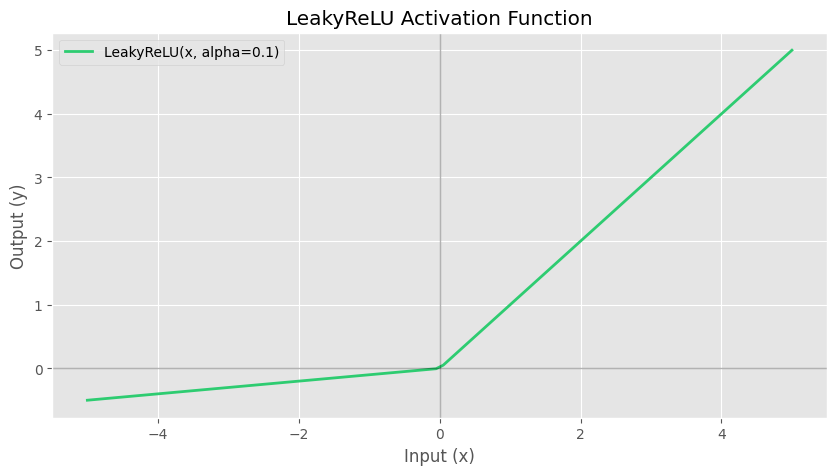

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sorix import tensor
from sorix.nn import LeakyReLU

plt.style.use('ggplot')

x_vals = np.linspace(-5, 5, 100)
X = tensor(x_vals, requires_grad=True)
leaky_relu = LeakyReLU(negative_slope=0.1)  # Using 0.1 for visibility in the plot
Y = leaky_relu(X)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, Y.data, label='LeakyReLU(x, alpha=0.1)', color='#2ecc71', linewidth=2)
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title('LeakyReLU Activation Function')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.grid(True)
plt.legend()
plt.show()

In [2]:
# Numerical demo with gradients
X = tensor([-2.0, -1.0, 0.0, 1.0, 2.0], requires_grad=True)
leaky_relu = LeakyReLU(negative_slope=0.01)
Y = leaky_relu(X)
Y.sum().backward()

print(f'Input:     {X.data}')
print(f'Output:    {Y.data}')
print(f'Gradients: {X.grad.data}') # Should be 0.01 for negative and 1.0 for positive

Input:     [-2. -1.  0.  1.  2.]
Output:    [-0.02 -0.01  0.    1.    2.  ]
Gradients: [0.01 0.01 0.01 1.   1.  ]
